Dataset Loaded Successfully
Shape : (57, 6)
  Teacher_Introduction Teaching_Skill Communication Subject_Knowledge  \
0            Puneeth T           High        Medium              High   
1             Vishal V           High          High              High   
2        Anjali Kumari         Medium        Medium            Medium   
3            Santosh R           High          High              High   
4                Mehak         Medium        Medium            Medium   

  Classroom_Management Overall_Label  
0                 High      Suitable  
1               Medium      Suitable  
2                 High      Suitable  
3                 High      Suitable  
4                 High      Suitable  

Cluster Distribution
Cluster
0    45
1    12
Name: count, dtype: int64

Fit Label Distribution
Fit
1    56
0     1
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Accuracy         : 100.0 %
Cross-Val Scores : [np.float64(100.0), np.float64(91.67), np.float64(100.0), np.float64(100.0), np.float64(100.0)]
Mean CV Accuracy : 98.33 %

Classification Report
                   precision    recall  f1-score   support

Needs Improvement       0.00      0.00      0.00         0
         Suitable       1.00      1.00      1.00        12

         accuracy                           1.00        12
        macro avg       0.50      0.50      0.50        12
     weighted avg       1.00      1.00      1.00        12


Prediction Result
FIT FOR THE JOB
Confidence: 100.0 %


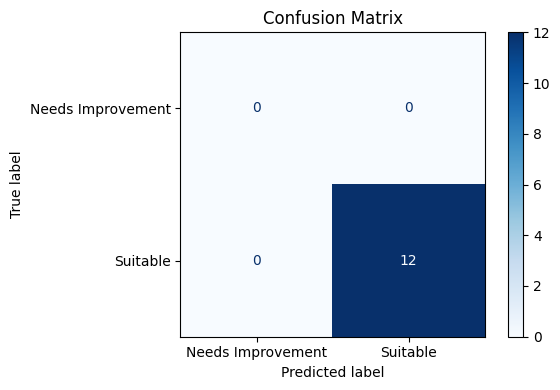

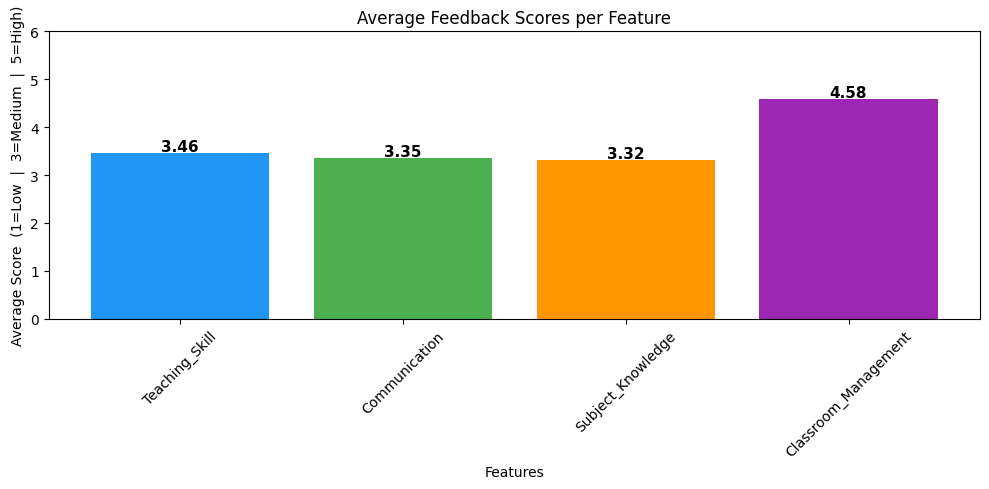

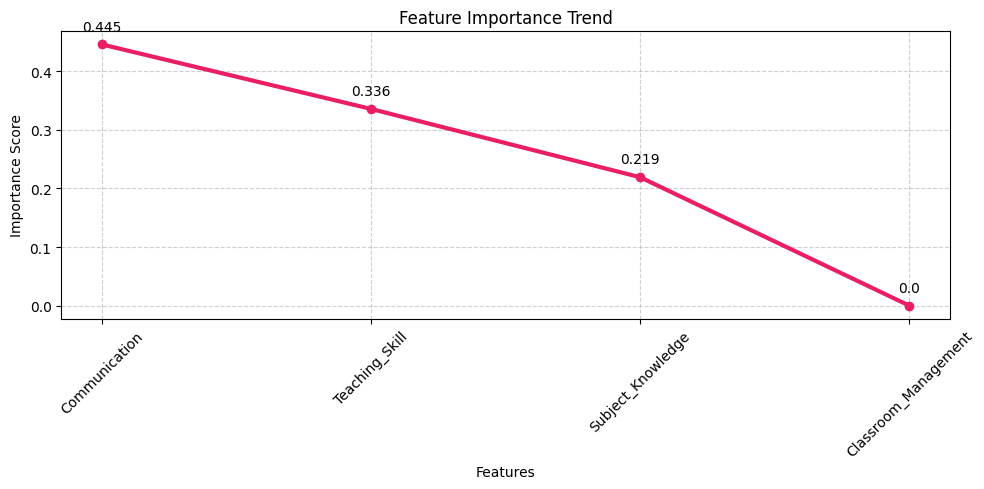

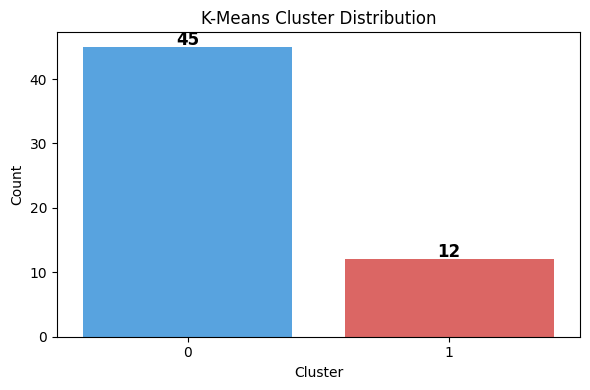

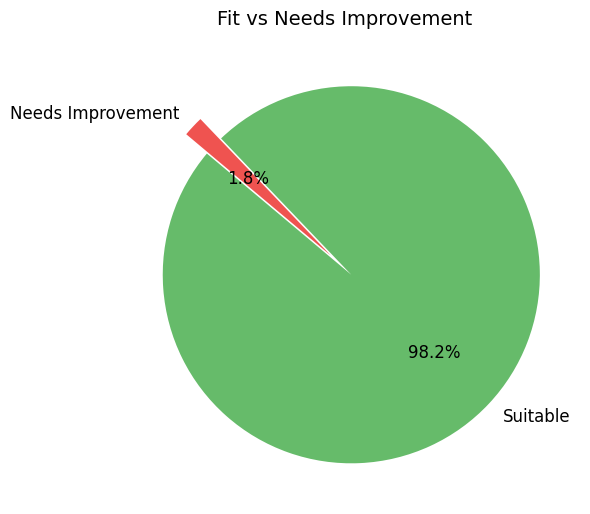

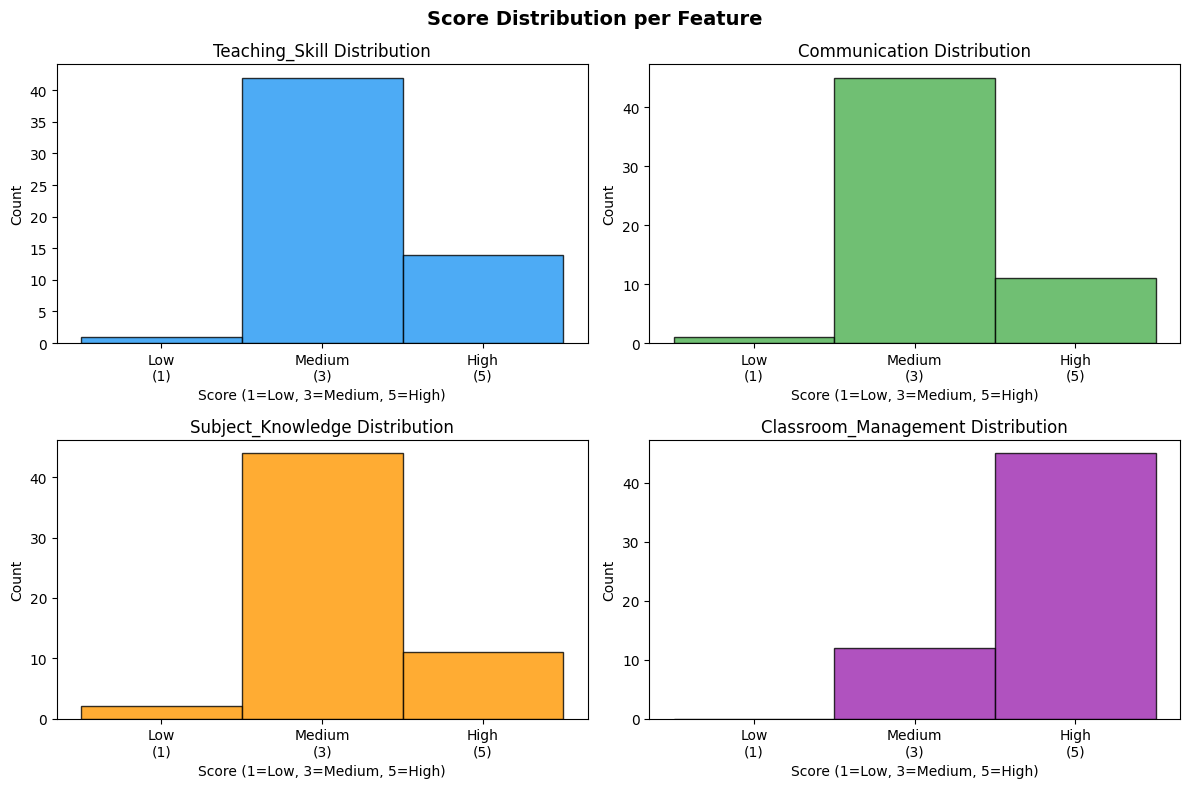

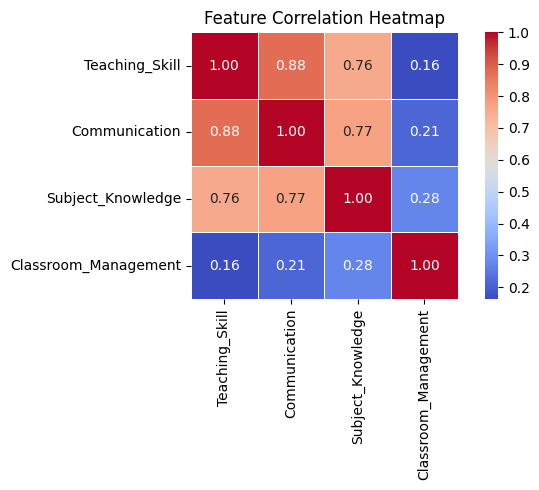

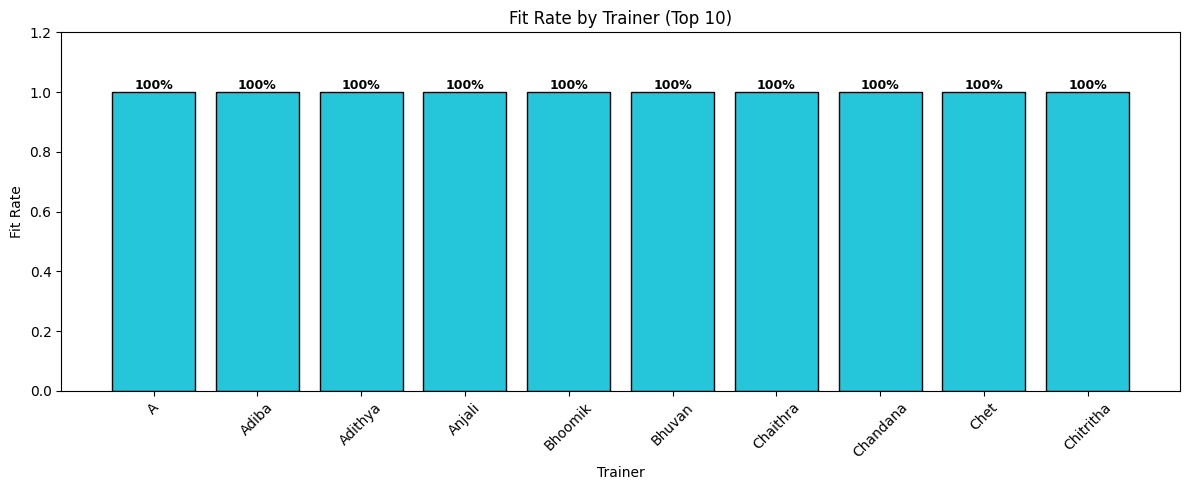


Project Completed Successfully


In [1]:
# ==========================================
# TEACHER FIT PREDICTION SYSTEM
# USING SUPERVISED + UNSUPERVISED LEARNING
# Dataset: Trainer FeedBack (Numbers File)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("trainer_feedback_dataset.csv")

print("Dataset Loaded Successfully")
print(f"Shape : {df.shape}")
print(df.head())

# ==========================================
# CONVERT CATEGORICAL FEEDBACK TO SCORES
# ==========================================

rating_map = {
    "High":   5,
    "Medium": 3,
    "Low":    1
}

for col in ["Teaching_Skill", "Communication",
            "Subject_Knowledge", "Classroom_Management"]:
    df[col] = df[col].map(rating_map)

# ==========================================
# FEATURE SELECTION
# ==========================================

features = [
    "Teaching_Skill",
    "Communication",
    "Subject_Knowledge",
    "Classroom_Management"
]

X = df[features]

# ==========================================
# UNSUPERVISED LEARNING — K-MEANS CLUSTERING
# ==========================================

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
df["Cluster"] = clusters

print("\nCluster Distribution")
print(df["Cluster"].value_counts())

# ==========================================
# CREATE FIT LABELS FROM OVERALL_LABEL
# ==========================================

df["Fit"] = np.where(df["Overall_Label"] == "Suitable", 1, 0)

print("\nFit Label Distribution")
print(df["Fit"].value_counts())

# ==========================================
# SUPERVISED LEARNING — RANDOM FOREST
# ==========================================

y = df["Fit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# MODEL EVALUATION
# ==========================================

pred     = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
cv_scores = cross_val_score(model, X, y, cv=5)

print("\nAccuracy         :", round(accuracy * 100, 2), "%")
print("Cross-Val Scores :", [round(s * 100, 2) for s in cv_scores])
print("Mean CV Accuracy :", round(cv_scores.mean() * 100, 2), "%")

print("\nClassification Report")
print(classification_report(
    y_test, pred,
    labels=[0, 1],
    target_names=["Needs Improvement", "Suitable"],
    zero_division=0
))

# ==========================================
# NEW TEACHER PREDICTION
# ==========================================

new_teacher = pd.DataFrame([[5, 5, 5, 5]], columns=features)

result      = model.predict(new_teacher)
probability = model.predict_proba(new_teacher)
confidence  = np.max(probability) * 100

print("\nPrediction Result")
print("FIT FOR THE JOB" if result[0] == 1 else "NOT FIT FOR THE JOB")
print("Confidence:", round(confidence, 2), "%")

# ==========================================
# GRAPH 1 — CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, pred, labels=[0, 1])

plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Needs Improvement", "Suitable"]
)
disp.plot(cmap="Blues", ax=plt.gca())
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2 — AVERAGE FEEDBACK SCORES (BAR)
# ==========================================

avg_scores = X.mean()

plt.figure(figsize=(10, 5))
bars = plt.bar(
    avg_scores.index,
    avg_scores.values,
    color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
)
for bar, val in zip(bars, avg_scores.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(round(val, 2)),
        ha='center', fontsize=11, fontweight='bold'
    )
plt.title("Average Feedback Scores per Feature")
plt.xlabel("Features")
plt.ylabel("Average Score  (1=Low  |  3=Medium  |  5=High)")
plt.ylim(0, 6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 3 — FEATURE IMPORTANCE (LINE)
# ==========================================

importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(
    importance_df['Feature'],
    importance_df['Importance'],
    marker='o', linewidth=3, color='#E91E63'
)
for _, row in importance_df.iterrows():
    plt.annotate(
        f"{round(row['Importance'], 3)}",
        (row['Feature'], row['Importance']),
        textcoords="offset points",
        xytext=(0, 10), ha='center', fontsize=10
    )
plt.title("Feature Importance Trend")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 4 — CLUSTER DISTRIBUTION (COUNT)
# ==========================================

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    x='Cluster', data=df,
    hue='Cluster',
    palette=['#42A5F5', '#EF5350'],
    legend=False
)
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
        ha='center', fontsize=12, fontweight='bold'
    )
plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 5 — PIE CHART: FIT vs NOT FIT
# ==========================================

fit_counts = df["Fit"].value_counts()
labels     = ["Suitable", "Needs Improvement"]
colors     = ['#66BB6A', '#EF5350']
explode    = (0.05, 0.1)

plt.figure(figsize=(6, 6))
plt.pie(
    fit_counts,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)
plt.title("Fit vs Needs Improvement", fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 6 — SCORE DISTRIBUTION (HISTOGRAM)
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors_hist = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (feat, color) in enumerate(zip(features, colors_hist)):
    axes[i].hist(
        df[feat], bins=[0, 2, 4, 6],
        color=color, edgecolor='black', alpha=0.8
    )
    axes[i].set_title(f"{feat} Distribution")
    axes[i].set_xlabel("Score (1=Low, 3=Medium, 5=High)")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks([1, 3, 5])
    axes[i].set_xticklabels(['Low\n(1)', 'Medium\n(3)', 'High\n(5)'])

plt.suptitle("Score Distribution per Feature", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 7 — CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(7, 5))
corr = X.corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 8 — SECTION-WISE FIT DISTRIBUTION
# ==========================================

section_fit = df.groupby(
    df["Teacher_Introduction"].str.split().str[0]
)["Fit"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(
    section_fit.index,
    section_fit.values,
    color='#26C6DA', edgecolor='black'
)
for bar, val in zip(bars, section_fit.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{round(val * 100)}%",
        ha='center', fontsize=9, fontweight='bold'
    )
plt.title("Fit Rate by Trainer (Top 10)")
plt.xlabel("Trainer")
plt.ylabel("Fit Rate")
plt.ylim(0, 1.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nProject Completed Successfully")